# 🏥 Indian Liver Patient Disease Prediction — Project 2
### End-to-End ML with Stacking Classifier & Advanced Analysis

**Dataset:** Indian Liver Patient Dataset (ILPD) — 583 records  
**Target:** Dataset (1 = Liver Disease, 2 = No Disease → converted to 0)  
**Key Features:** Total_Bilirubin, Direct_Bilirubin, SGPT (ALT), SGOT (AST), Alkaline_Phosphatase  
**Special Feature:** 🔥 Advanced Stacking Classifier on Hybrid Dataset  


## 🟢 STEP 1: Import Libraries
We import all required libraries for data handling, visualization, ML training, and evaluation.

In [1]:
# ── Data Handling ──
import numpy as np
import pandas as pd

# ── Visualization ──
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Preprocessing ──
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ── Class Imbalance ──
from imblearn.over_sampling import SMOTE

# ── ML Models ──
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Evaluation ──
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    roc_curve
)

# ── Utilities ──
import pickle, warnings
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

# ── Important feature columns (Project 2 specification) ──
IMPORTANT_FEATURES = [
    'Total_Bilirubin', 'Direct_Bilirubin',
    'Alamine_Aminotransferase',   # SGPT
    'Aspartate_Aminotransferase', # SGOT
    'Alkaline_Phosphotase'
]

print('✅ All libraries imported!')
print('📌 Important Features:', IMPORTANT_FEATURES)


✅ All libraries imported!
📌 Important Features: ['Total_Bilirubin', 'Direct_Bilirubin', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Alkaline_Phosphotase']


## 🟢 STEP 2: Load Dataset

In [2]:
df = pd.read_csv('data/indian_liver_patient.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()


Shape: (583, 11)
Columns: ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset']


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [4]:
print('Missing values:')
print(df.isnull().sum())
print('\nClass distribution (raw):')
print(df['Dataset'].value_counts())


Missing values:
Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

Class distribution (raw):
Dataset
1    416
2    167
Name: count, dtype: int64


## 🟢 STEP 3: Data Preprocessing
Each sub-step is in its own cell for clarity.

### 3.1 Handle Missing Values

In [5]:
# Fill missing Albumin_and_Globulin_Ratio with median
df['Albumin_and_Globulin_Ratio'].fillna(
    df['Albumin_and_Globulin_Ratio'].median(), inplace=True
)
print('Missing values after fix:', df.isnull().sum().sum())


Missing values after fix: 0


### 3.2 Label Encode Gender (Male=1, Female=0)

In [6]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print('Gender encoded. Value counts:', df['Gender'].value_counts().to_dict())


Gender encoded. Value counts: {1: 441, 0: 142}


### 3.3 Remap Target: 1→1 (Disease), 2→0 (No Disease)

In [7]:
df['Dataset'] = df['Dataset'].map({1: 1, 2: 0})
print('Target distribution:', df['Dataset'].value_counts().to_dict())
print('1 = Liver Disease | 0 = No Disease')


Target distribution: {1: 416, 0: 167}
1 = Liver Disease | 0 = No Disease


### 3.4 Feature Scaling (StandardScaler) — Applied on Important Features

In [8]:
# ── Prepare datasets for modeling ──
# (A) Important Features only — used for main modeling
X_imp = df[IMPORTANT_FEATURES].copy()
y     = df['Dataset'].copy()

# (B) All features — kept separately for full-feature mode
X_all = df.drop('Dataset', axis=1).copy()

# Scale both
scaler_imp = StandardScaler()
X_imp_sc   = pd.DataFrame(scaler_imp.fit_transform(X_imp), columns=IMPORTANT_FEATURES)

scaler_all = StandardScaler()
X_all_sc   = pd.DataFrame(scaler_all.fit_transform(X_all), columns=X_all.columns)

print('Important Features scaled shape:', X_imp_sc.shape)
print('All Features scaled shape:', X_all_sc.shape)


Important Features scaled shape: (583, 5)
All Features scaled shape: (583, 10)


### 3.5 Handle Class Imbalance with SMOTE

In [9]:
smote = SMOTE(random_state=SEED)
X_bal, y_bal = smote.fit_resample(X_imp_sc, y)

print('Before SMOTE:', dict(y.value_counts()))
print('After  SMOTE:', dict(pd.Series(y_bal).value_counts()))
print('\nSMOTE creates synthetic minority-class samples to balance the dataset.')


Before SMOTE: {1: np.int64(416), 0: np.int64(167)}
After  SMOTE: {1: np.int64(416), 0: np.int64(416)}

SMOTE creates synthetic minority-class samples to balance the dataset.


## 🟢 STEP 4: Exploratory Data Analysis (EDA)

In [10]:
# Summary statistics
print('Summary Statistics (Important Features + Target):')
df[IMPORTANT_FEATURES + ['Dataset']].describe().round(2)


Summary Statistics (Important Features + Target):


,Total_Bilirubin,Direct_Bilirubin,Alamine_Aminotransferase,Aspartate_Aminotransferase,Alkaline_Phosphotase,Dataset
count,583.00,583.00,583.00,583.00,583.00,583.00
mean,3.30,1.49,80.71,109.91,290.58,0.71
std,6.21,2.81,182.62,288.92,242.94,0.45
min,0.40,0.10,10.00,10.00,63.00,0.00
25%,0.80,0.20,23.00,25.00,175.50,0.00
50%,1.00,0.30,35.00,42.00,208.00,1.00
75%,2.60,1.30,60.50,87.00,298.00,1.00
max,75.00,19.70,2000.00,4929.00,2110.00,1.00


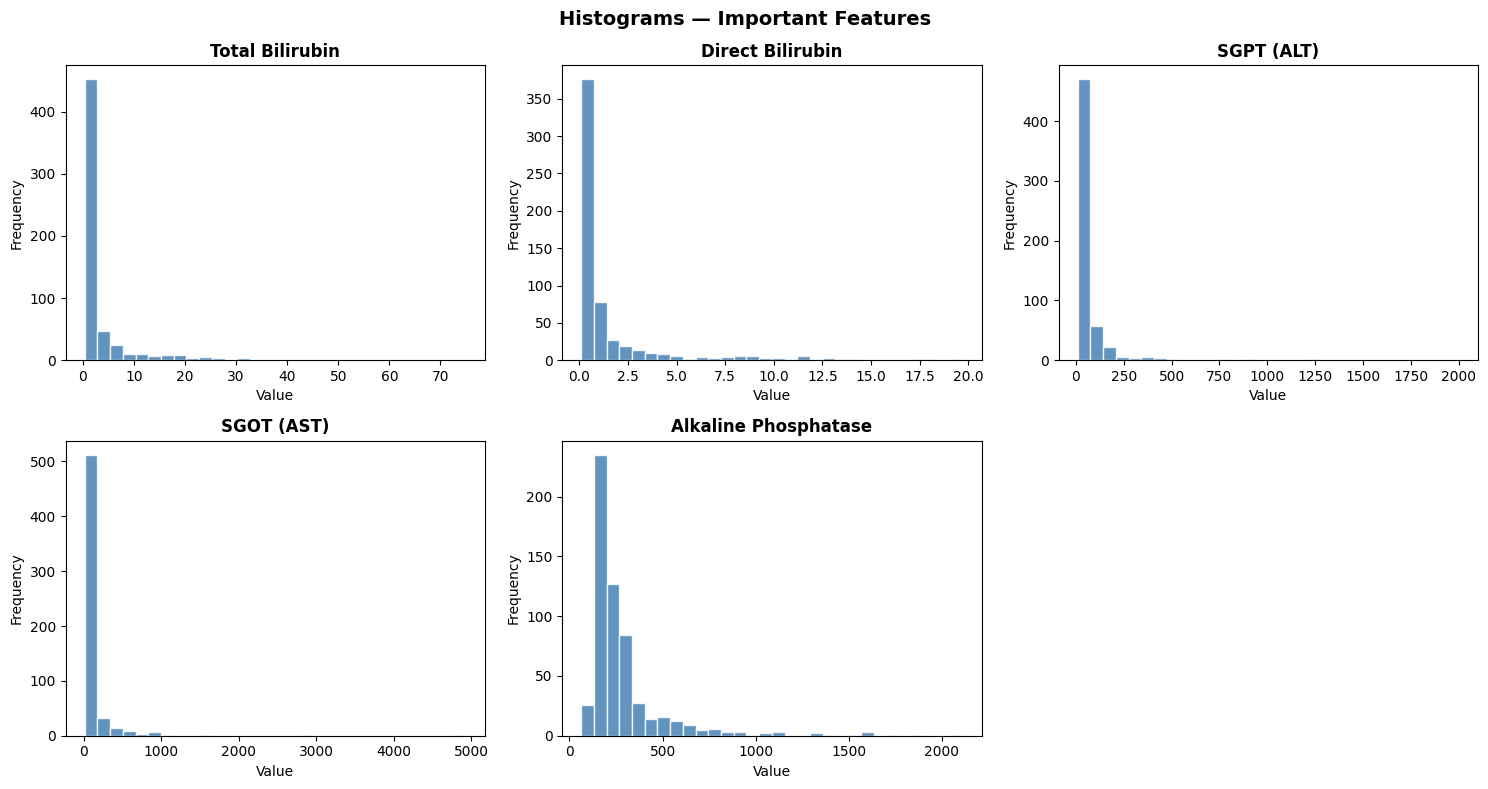

📌 Insight: All enzyme/bilirubin features are right-skewed — extreme values indicate liver dysfunction.


In [11]:
# ── Histograms for Important Features ──
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
labels = ['Total Bilirubin', 'Direct Bilirubin', 'SGPT (ALT)', 'SGOT (AST)', 'Alkaline Phosphatase']

for i, (col, lbl) in enumerate(zip(IMPORTANT_FEATURES, labels)):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(lbl, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[5].set_visible(False)
plt.suptitle('Histograms — Important Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('2hist_important.png', dpi=100, bbox_inches='tight')
plt.show()
print('📌 Insight: All enzyme/bilirubin features are right-skewed — extreme values indicate liver dysfunction.')


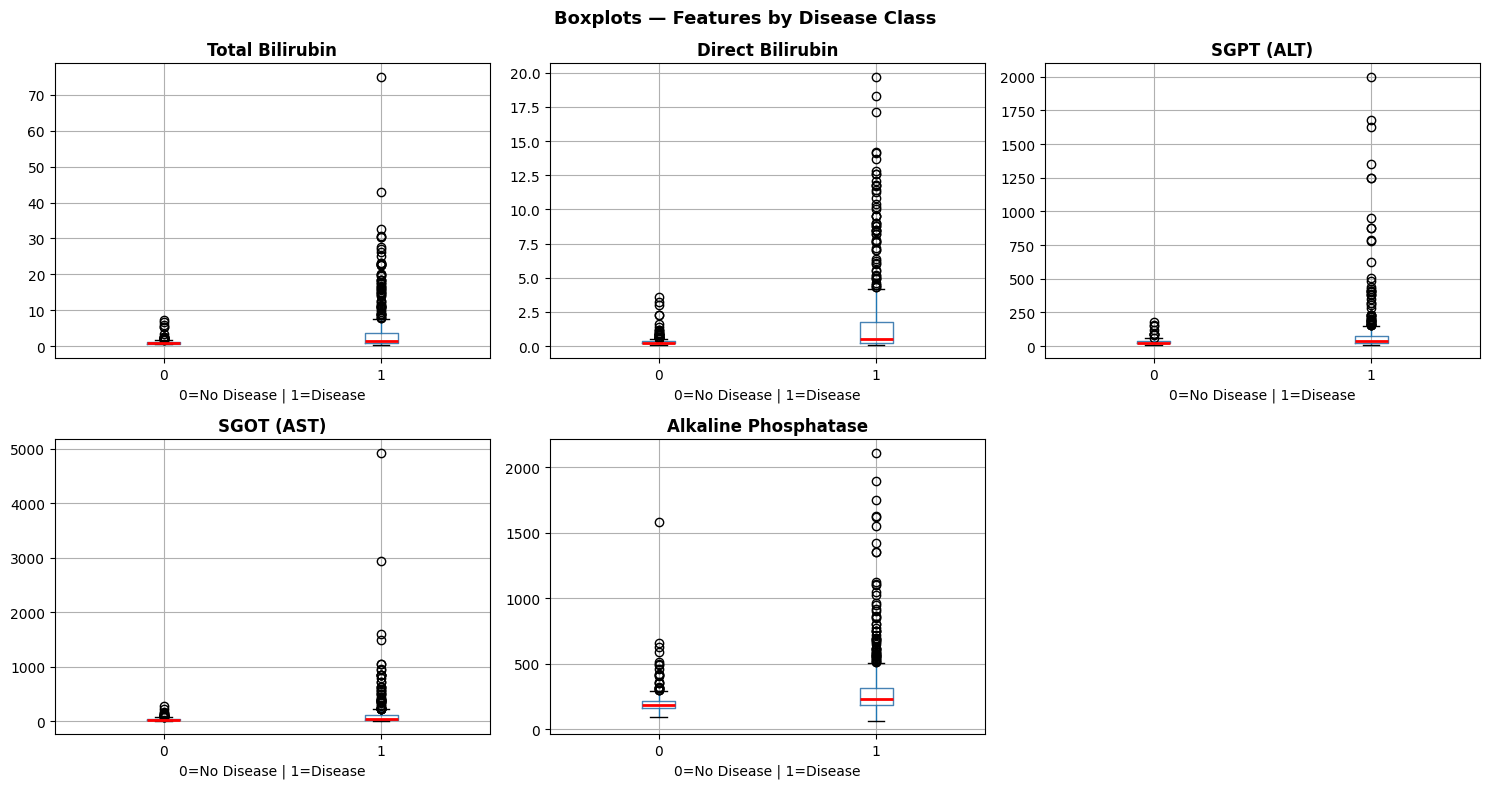

📌 Insight: Liver disease patients show significantly higher enzyme values (outliers).


In [12]:
# ── Boxplots: Feature vs Disease Class ──
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, lbl) in enumerate(zip(IMPORTANT_FEATURES, labels)):
    df.boxplot(column=col, by='Dataset', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(lbl, fontweight='bold')
    axes[i].set_xlabel('0=No Disease | 1=Disease')
    plt.setp(axes[i].get_xticklabels(), rotation=0)

axes[5].set_visible(False)
plt.suptitle('Boxplots — Features by Disease Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=100, bbox_inches='tight')
plt.show()
print('📌 Insight: Liver disease patients show significantly higher enzyme values (outliers).')


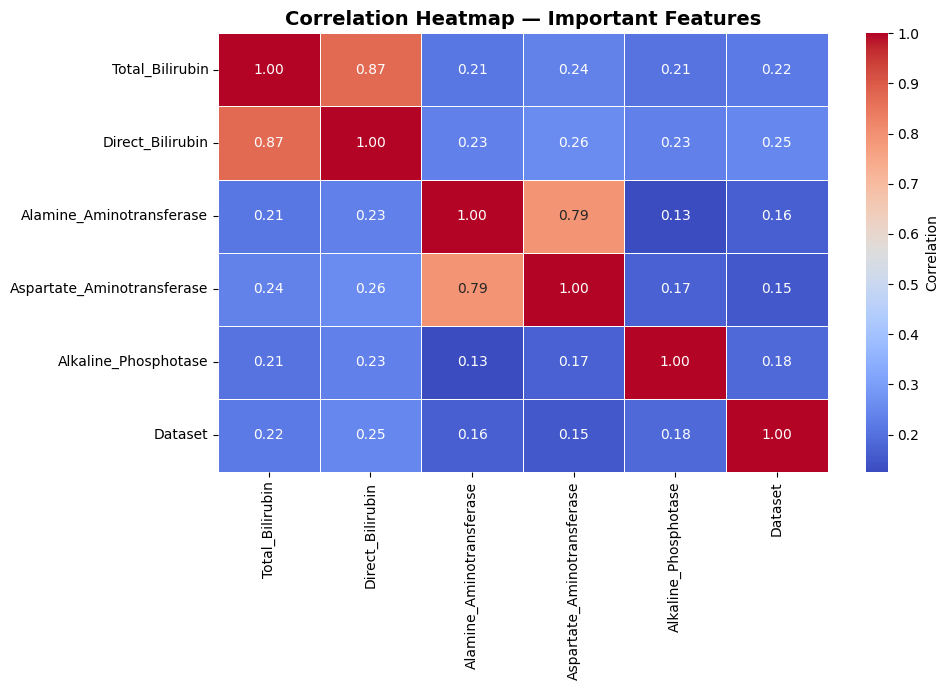

📌 Insight: Total & Direct Bilirubin are highly correlated. SGPT & SGOT also show strong correlation.


In [13]:
# ── Correlation Heatmap ──
plt.figure(figsize=(10, 7))
corr = df[IMPORTANT_FEATURES + ['Dataset']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap — Important Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('2heatmap_imp.png', dpi=100, bbox_inches='tight')
plt.show()
print('📌 Insight: Total & Direct Bilirubin are highly correlated. SGPT & SGOT also show strong correlation.')


## 🟢 STEP 5: Create Age-Based, Gender-Based & Hybrid Datasets

In [14]:
# Keep working copy with important features + group cols
df_work = df[IMPORTANT_FEATURES + ['Age', 'Gender', 'Dataset']].copy()

# ── Age Groups ──
df_work['AgeGroup'] = pd.cut(df_work['Age'],
                              bins=[0, 30, 50, 200],
                              labels=['Young', 'Middle', 'Senior'])

df_young  = df_work[df_work['AgeGroup'] == 'Young'].copy()
df_middle = df_work[df_work['AgeGroup'] == 'Middle'].copy()
df_senior = df_work[df_work['AgeGroup'] == 'Senior'].copy()

# ── Gender Groups ──
df_male   = df_work[df_work['Gender'] == 1].copy()
df_female = df_work[df_work['Gender'] == 0].copy()

# ── Hybrid Groups ──
df_work['GenderLabel'] = df_work['Gender'].map({1: 'Male', 0: 'Female'})
df_work['Hybrid']      = df_work['AgeGroup'].astype(str) + '_' + df_work['GenderLabel']

print('Dataset split summary:')
for name, sub in [('Young', df_young), ('Middle', df_middle), ('Senior', df_senior),
                   ('Male', df_male), ('Female', df_female)]:
    print(f'  {name:8s}: {len(sub)} rows')
print('  Hybrid groups:', df_work['Hybrid'].value_counts().to_dict())


Dataset split summary:
  Young   : 115 rows
  Middle  : 261 rows
  Senior  : 207 rows
  Male    : 441 rows
  Female  : 142 rows
  Hybrid groups: {'Middle_Male': 192, 'Senior_Male': 168, 'Young_Male': 81, 'Middle_Female': 69, 'Senior_Female': 39, 'Young_Female': 34}


## 🟢 STEP 6: Model Training Helpers
We define helper functions to avoid repeating the same code for each dataset split.

In [15]:
def prepare_split(subset_df):
    """
    Takes a subset DataFrame, drops group columns,
    scales features, applies SMOTE, returns train/test split.
    """
    drop = [c for c in ['Age','Gender','AgeGroup','GenderLabel','Hybrid']
            if c in subset_df.columns]
    data = subset_df.drop(columns=drop)
    X = data[IMPORTANT_FEATURES]
    y = data['Dataset']

    if y.nunique() < 2 or len(y) < 20:
        return None

    sc = StandardScaler()
    X_sc = sc.fit_transform(X)

    minority = y.value_counts().min()
    if minority >= 6:
        k = min(5, minority - 1)
        sm = SMOTE(random_state=SEED, k_neighbors=k)
        X_sc, y = sm.fit_resample(X_sc, y)

    return train_test_split(X_sc, y, test_size=0.2, random_state=SEED, stratify=y), sc


def get_models():
    return {
        'Logistic Regression': LogisticRegression(random_state=SEED, max_iter=1000),
        'Decision Tree':       DecisionTreeClassifier(random_state=SEED),
        'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=SEED),
        'SVM':                 SVC(probability=True, random_state=SEED),
        'XGBoost':             XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0),
        'LightGBM':            LGBMClassifier(random_state=SEED, verbose=-1),
    }


def eval_model(model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_prob  = model.predict_proba(X_te)[:, 1]
    return {
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_te, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_te, y_prob), 4),
    }


def run_all_models(subset_df, label=''):
    out = prepare_split(subset_df)
    if out is None:
        print(f'  ⚠️  Skipping {label}: not enough data')
        return None, None, None
    (X_tr, X_te, y_tr, y_te), sc = out
    rows, trained = [], {}
    for name, m in get_models().items():
        metrics = eval_model(m, X_tr, X_te, y_tr, y_te)
        metrics.update({'Model': name, 'Group': label})
        rows.append(metrics)
        trained[name] = m
    df_r = pd.DataFrame(rows)[['Group','Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC']]
    return df_r, trained, (X_tr, X_te, y_tr, y_te)

print('✅ Helper functions ready!')


✅ Helper functions ready!


### Model Training on Full Balanced Dataset
Each model is trained separately for clarity.

In [16]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=SEED, stratify=y_bal
)
full_trained = {}
full_results = []

for name, m in get_models().items():
    metrics = eval_model(m, X_tr, X_te, y_tr, y_te)
    metrics['Model'] = name
    full_results.append(metrics)
    full_trained[name] = m

full_df = pd.DataFrame(full_results)[['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC']]
print('Full Dataset Results:')
full_df


Full Dataset Results:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7365,0.8824,0.5422,0.6716,0.8012
1,Decision Tree,0.6647,0.6753,0.6265,0.6500,0.6644
2,Random Forest,0.8084,0.8493,0.7470,0.7949,0.8683
3,SVM,0.7365,0.8980,0.5301,0.6667,0.8012
4,XGBoost,0.7964,0.8267,0.7470,0.7848,0.8731
5,LightGBM,0.7904,0.8243,0.7349,0.7771,0.8477


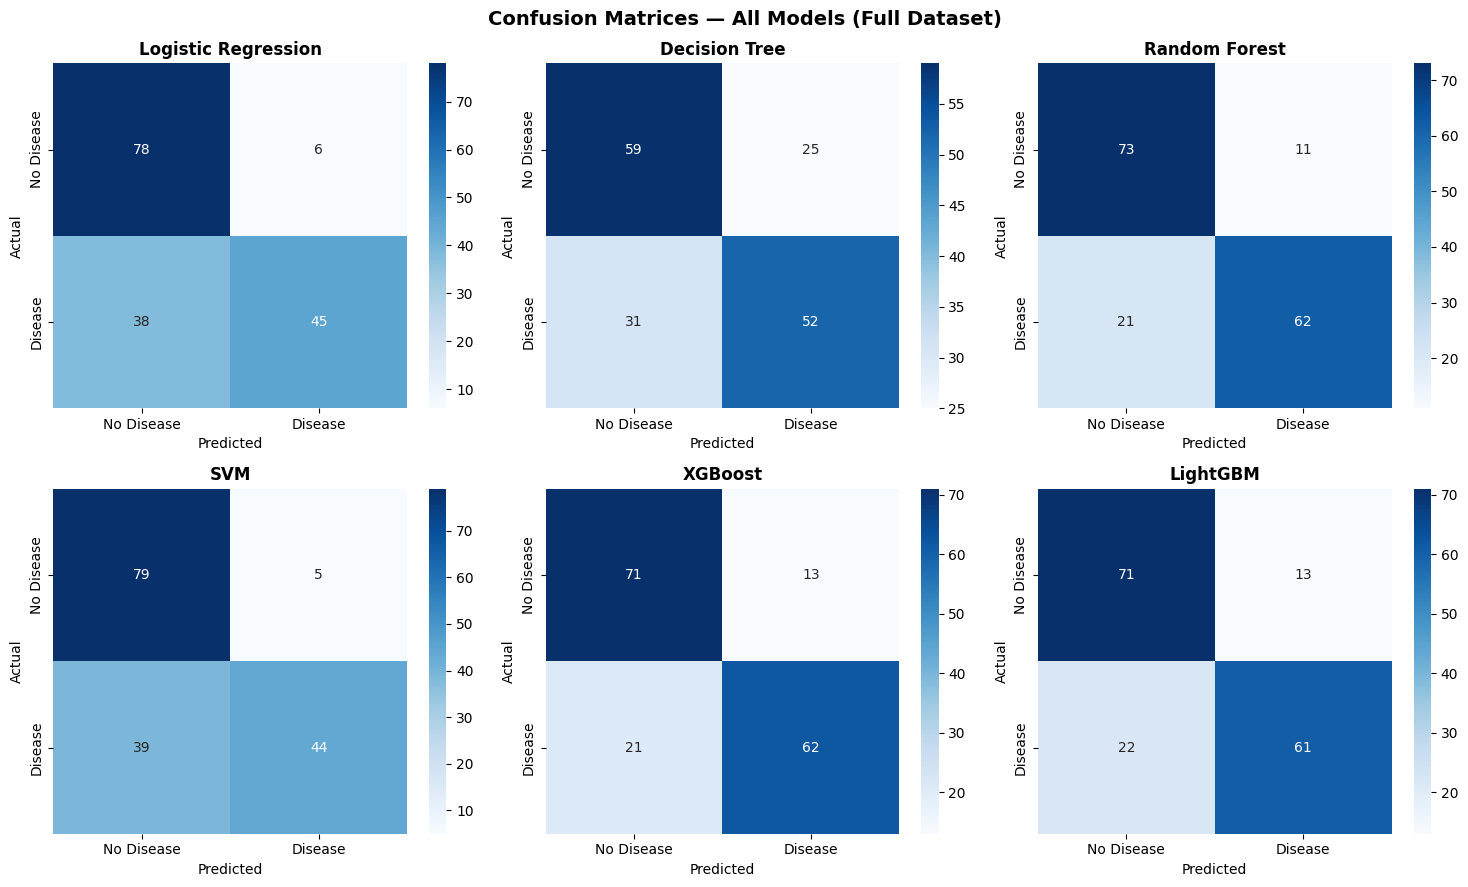

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (name, m) in enumerate(full_trained.items()):
    cm = confusion_matrix(y_te, m.predict(X_te))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Disease','Disease'],
                yticklabels=['No Disease','Disease'])
    axes[idx].set_title(name, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models (Full Dataset)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('2cm_full.png', dpi=100, bbox_inches='tight')
plt.show()


## 🟢 STEP 7: Evaluation Per Category
Train and evaluate all 6 models on each sub-dataset.

### 7A: Age-Based Results

In [18]:
age_all, age_trained, age_splits = [], {}, {}

for grp, sub in [('Young', df_young), ('Middle', df_middle), ('Senior', df_senior)]:
    print(f'→ Age Group: {grp}')
    res, tr, sp = run_all_models(sub, grp)
    if res is not None:
        age_all.append(res)
        age_trained[grp] = tr
        age_splits[grp]  = sp

age_df = pd.concat(age_all, ignore_index=True)
print('\n📊 Age-Based Evaluation Table:')
age_df


→ Age Group: Young
→ Age Group: Middle
→ Age Group: Senior

📊 Age-Based Evaluation Table:


,Group,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Young,Logistic Regression,0.6154,0.6154,0.6154,0.6154,0.5444
1,Young,Decision Tree,0.6538,0.6429,0.6923,0.6667,0.6538
2,Young,Random Forest,0.6154,0.6000,0.6923,0.6429,0.5976
3,Young,SVM,0.5000,0.5000,0.3846,0.4348,0.5089
4,Young,XGBoost,0.5769,0.5625,0.6923,0.6207,0.7041
5,Young,LightGBM,0.6154,0.5882,0.7692,0.6667,0.6450
6,Middle,Logistic Regression,0.5641,0.5806,0.4615,0.5143,0.6226
7,Middle,Decision Tree,0.7179,0.7576,0.6410,0.6944,0.7179
8,Middle,Random Forest,0.7692,0.7838,0.7436,0.7632,0.8731
9,Middle,SVM,0.5641,0.5862,0.4359,0.5000,0.6298


### 7B: Gender-Based Results

In [19]:
gender_all, gender_trained, gender_splits = [], {}, {}

for grp, sub in [('Male', df_male), ('Female', df_female)]:
    print(f'→ Gender Group: {grp}')
    res, tr, sp = run_all_models(sub, grp)
    if res is not None:
        gender_all.append(res)
        gender_trained[grp] = tr
        gender_splits[grp]  = sp

gender_df = pd.concat(gender_all, ignore_index=True)
print('\n📊 Gender-Based Evaluation Table:')
gender_df


→ Gender Group: Male
→ Gender Group: Female

📊 Gender-Based Evaluation Table:


,Group,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Male,Logistic Regression,0.6923,0.7778,0.5385,0.6364,0.7910
1,Male,Decision Tree,0.8077,0.8226,0.7846,0.8031,0.8077
2,Male,Random Forest,0.8231,0.8387,0.8000,0.8189,0.8923
3,Male,SVM,0.7231,0.8085,0.5846,0.6786,0.7946
4,Male,XGBoost,0.8000,0.8095,0.7846,0.7969,0.8847
5,Male,LightGBM,0.7692,0.7778,0.7538,0.7656,0.8677
6,Female,Logistic Regression,0.6757,0.7500,0.5000,0.6000,0.7164
7,Female,Decision Tree,0.7027,0.6842,0.7222,0.7027,0.7032
8,Female,Random Forest,0.7838,0.7500,0.8333,0.7895,0.8596
9,Female,SVM,0.5946,0.6667,0.3333,0.4444,0.6784


### 7C: Hybrid Results

In [20]:
hybrid_all, hybrid_trained, hybrid_splits = [], {}, {}

for grp, sub in df_work.groupby('Hybrid'):
    res, tr, sp = run_all_models(sub.copy(), grp)
    if res is not None:
        hybrid_all.append(res)
        hybrid_trained[grp] = tr
        hybrid_splits[grp]  = sp

hybrid_df = pd.concat(hybrid_all, ignore_index=True)
print('\n📊 Hybrid Evaluation Table:')
hybrid_df



📊 Hybrid Evaluation Table:


,Group,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Middle_Female,Logistic Regression,0.7500,1.0000,0.5000,0.6667,0.7900
1,Middle_Female,Decision Tree,0.6500,0.6364,0.7000,0.6667,0.6500
2,Middle_Female,Random Forest,0.7000,0.6667,0.8000,0.7273,0.8600
3,Middle_Female,SVM,0.7000,1.0000,0.4000,0.5714,0.7800
4,Middle_Female,XGBoost,0.7500,0.6923,0.9000,0.7826,0.8100
5,Middle_Female,LightGBM,0.6500,0.6364,0.7000,0.6667,0.7700
6,Middle_Male,Logistic Regression,0.6102,0.6875,0.3793,0.4889,0.6977
7,Middle_Male,Decision Tree,0.6949,0.6897,0.6897,0.6897,0.6948
8,Middle_Male,Random Forest,0.7288,0.7600,0.6552,0.7037,0.8672
9,Middle_Male,SVM,0.7119,0.8000,0.5517,0.6531,0.7621


## 🟢 STEP 8: 🔥 Advanced Stacking Classifier (Hybrid Dataset)
**Stacking** is an ensemble method where predictions of base models are used as
features to train a meta-model. This often outperforms any single model.

### STEP 8.1 — Define Base Models

In [21]:
# Base models: Random Forest, SVM, XGBoost
base_rf  = RandomForestClassifier(n_estimators=100, random_state=SEED)
base_svm = SVC(probability=True, random_state=SEED)
base_xgb = XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0)

print('Base Models defined:')
print('  1. Random Forest')
print('  2. SVM (probability=True)')
print('  3. XGBoost')


Base Models defined:
  1. Random Forest
  2. SVM (probability=True)
  3. XGBoost


### STEP 8.2 — Define Meta Model

In [22]:
# Meta-model: Logistic Regression
meta_model = LogisticRegression(random_state=SEED, max_iter=1000)
print('Meta Model: Logistic Regression')
print('Role: Learns from base model predictions to make the final decision.')


Meta Model: Logistic Regression
Role: Learns from base model predictions to make the final decision.


### STEP 8.3 — Build Stacking Classifier

In [23]:
# Build the stacking ensemble
stacking_clf = StackingClassifier(
    estimators=[
        ('rf',  base_rf),
        ('svm', base_svm),
        ('xgb', base_xgb),
    ],
    final_estimator=meta_model,
    cv=5,          # 5-fold cross-validation to generate base predictions
    stack_method='predict_proba'
)

print('StackingClassifier built with cv=5')
print('Architecture: [RF + SVM + XGB] → Logistic Regression')


StackingClassifier built with cv=5
Architecture: [RF + SVM + XGB] → Logistic Regression


### STEP 8.4 — Train Stacking Model on Full Hybrid Data

In [24]:
# Use all hybrid-labeled data as one combined hybrid training set
df_hybrid_full = df_work.copy()
drop_h = [c for c in ['Age','Gender','AgeGroup','GenderLabel','Hybrid']
          if c in df_hybrid_full.columns]
df_hybrid_full = df_hybrid_full.drop(columns=drop_h)

X_h = df_hybrid_full[IMPORTANT_FEATURES]
y_h = df_hybrid_full['Dataset']

sc_h     = StandardScaler()
X_h_sc   = sc_h.fit_transform(X_h)
sm_h     = SMOTE(random_state=SEED)
X_h_bal, y_h_bal = sm_h.fit_resample(X_h_sc, y_h)

X_h_tr, X_h_te, y_h_tr, y_h_te = train_test_split(
    X_h_bal, y_h_bal, test_size=0.2, random_state=SEED, stratify=y_h_bal
)

print('Training Stacking Classifier (this may take a moment)...')
stacking_clf.fit(X_h_tr, y_h_tr)
print('✅ Stacking Classifier trained!')


Training Stacking Classifier (this may take a moment)...
✅ Stacking Classifier trained!


### STEP 8.5 — Evaluate Stacking Model

In [25]:
y_stack_pred  = stacking_clf.predict(X_h_te)
y_stack_proba = stacking_clf.predict_proba(X_h_te)[:, 1]

stack_metrics = {
    'Model':     '⭐ Stacking Classifier',
    'Accuracy':  round(accuracy_score(y_h_te, y_stack_pred), 4),
    'Precision': round(precision_score(y_h_te, y_stack_pred, zero_division=0), 4),
    'Recall':    round(recall_score(y_h_te, y_stack_pred, zero_division=0), 4),
    'F1-Score':  round(f1_score(y_h_te, y_stack_pred, zero_division=0), 4),
    'ROC-AUC':   round(roc_auc_score(y_h_te, y_stack_proba), 4),
}

print('📊 Stacking Classifier Evaluation:')
pd.DataFrame([stack_metrics])


📊 Stacking Classifier Evaluation:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,⭐ Stacking Classifier,0.8084,0.84,0.759,0.7975,0.8788


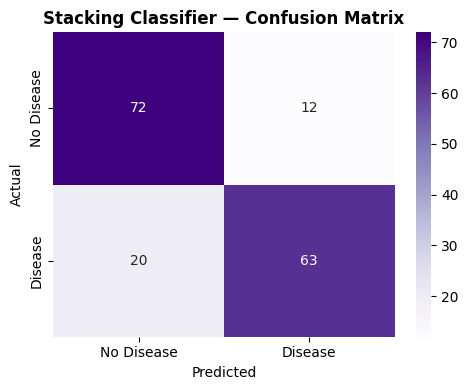

In [26]:
# Confusion matrix for Stacking
fig, ax = plt.subplots(figsize=(5, 4))
cm_stack = confusion_matrix(y_h_te, y_stack_pred)
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])
ax.set_title('Stacking Classifier — Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('2cm_stacking.png', dpi=100, bbox_inches='tight')
plt.show()


## 🟢 STEP 9: 🔥 Final Hybrid Comparison (Including Stacking)

In [27]:
# Run all 6 standard models on full hybrid set
hybrid_full_results = []
hybrid_full_trained = {}

for name, m in get_models().items():
    metrics = eval_model(m, X_h_tr, X_h_te, y_h_tr, y_h_te)
    metrics['Model'] = name
    hybrid_full_results.append(metrics)
    hybrid_full_trained[name] = m

# Add stacking result
hybrid_full_results.append(stack_metrics)

hybrid_final_df = pd.DataFrame(hybrid_full_results)[
    ['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC']
]

print('📊 FINAL HYBRID COMPARISON TABLE (including Stacking):')
hybrid_final_df


📊 FINAL HYBRID COMPARISON TABLE (including Stacking):


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7365,0.8824,0.5422,0.6716,0.8012
1,Decision Tree,0.6647,0.6753,0.6265,0.6500,0.6644
2,Random Forest,0.8084,0.8493,0.7470,0.7949,0.8683
3,SVM,0.7365,0.8980,0.5301,0.6667,0.8012
4,XGBoost,0.7964,0.8267,0.7470,0.7848,0.8731
5,LightGBM,0.7904,0.8243,0.7349,0.7771,0.8477
6,⭐ Stacking Classifier,0.8084,0.8400,0.7590,0.7975,0.8788


🏆 Best Hybrid Model (ROC-AUC): ⭐ Stacking Classifier — AUC=0.8788
🩺 Best Recall   (Hybrid)     : ⭐ Stacking Classifier — Recall=0.759


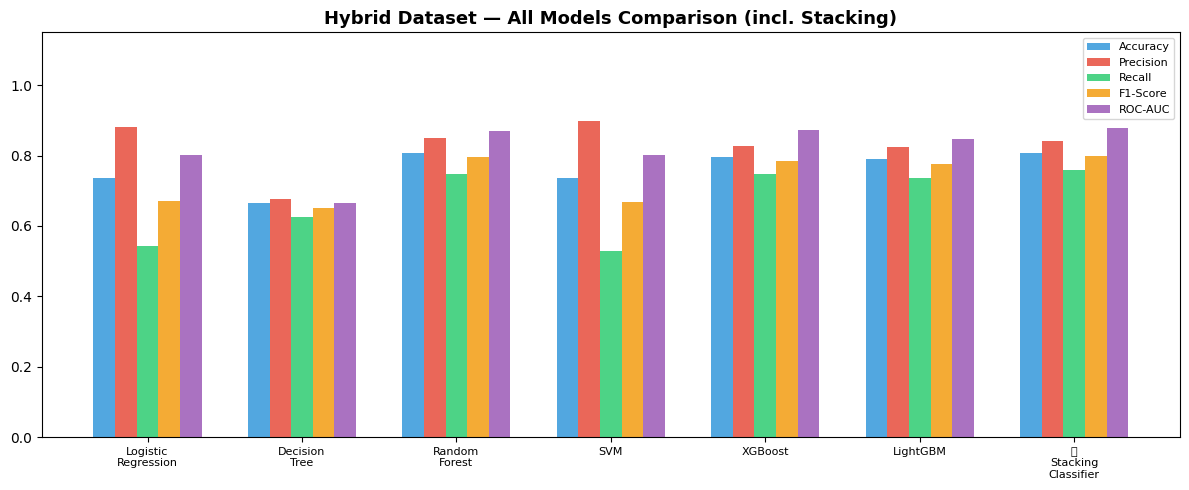

In [28]:
# Highlight best model
best_hybrid = hybrid_final_df.sort_values('ROC-AUC', ascending=False).iloc[0]
best_recall_hybrid = hybrid_final_df.sort_values('Recall', ascending=False).iloc[0]

print(f'🏆 Best Hybrid Model (ROC-AUC): {best_hybrid["Model"]} — AUC={best_hybrid["ROC-AUC"]}')
print(f'🩺 Best Recall   (Hybrid)     : {best_recall_hybrid["Model"]} — Recall={best_recall_hybrid["Recall"]}')

# Visual bar chart comparison
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(hybrid_final_df))
width = 0.14
metrics_list = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']

for i, (m, c) in enumerate(zip(metrics_list, colors)):
    ax.bar(x + i*width, hybrid_final_df[m], width, label=m, color=c, alpha=0.85)

ax.set_xticks(x + 2*width)
ax.set_xticklabels([n.replace(' ','\n') for n in hybrid_final_df['Model']], fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_title('Hybrid Dataset — All Models Comparison (incl. Stacking)', fontweight='bold', fontsize=13)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('2hybrid_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


## 🟢 STEP 10: Final Overall Evaluation

In [29]:
# Table 1: Best Model per Dataset Type
print('=' * 60)
print('TABLE 1: Best Model per Dataset Type')
print('=' * 60)

for dtype, df_r in [('Age-Based', age_df), ('Gender-Based', gender_df), ('Hybrid', hybrid_df)]:
    best = df_r.sort_values('ROC-AUC', ascending=False).iloc[0]
    best_rec = df_r.sort_values('Recall', ascending=False).iloc[0]
    print(f'\n{dtype}:')
    print(f'  Best (ROC-AUC) : {best["Model"]} [Group={best["Group"]}] — AUC={best["ROC-AUC"]}')
    print(f'  Best (Recall)  : {best_rec["Model"]} [Group={best_rec["Group"]}] — Recall={best_rec["Recall"]}')


TABLE 1: Best Model per Dataset Type

Age-Based:
  Best (ROC-AUC) : Random Forest [Group=Senior] — AUC=0.9014
  Best (Recall)  : XGBoost [Group=Middle] — Recall=0.7949

Gender-Based:
  Best (ROC-AUC) : Random Forest [Group=Male] — AUC=0.8923
  Best (Recall)  : XGBoost [Group=Female] — Recall=0.8889

Hybrid:
  Best (ROC-AUC) : LightGBM [Group=Senior_Male] — AUC=0.963
  Best (Recall)  : Logistic Regression [Group=Senior_Female] — Recall=1.0


In [30]:
# Table 2: Overall Comparison — Full Dataset
full_with_group = full_df.copy()
full_with_group.insert(0, 'Dataset Type', 'Full Dataset')

print('=' * 60)
print('TABLE 2: Full Dataset — All Models')
print('=' * 60)
print(full_df.to_string(index=False))

best_overall = full_df.sort_values('ROC-AUC', ascending=False).iloc[0]
best_recall  = full_df.sort_values('Recall', ascending=False).iloc[0]

print(f'\n🏆 Best Overall     : {best_overall["Model"]} (ROC-AUC={best_overall["ROC-AUC"]})')
print(f'🩺 Best for Recall  : {best_recall["Model"]} (Recall={best_recall["Recall"]})')
print('\nℹ️  High Recall = Fewer missed disease cases. Critical in medical diagnosis!')


TABLE 2: Full Dataset — All Models
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7365     0.8824  0.5422    0.6716   0.8012
      Decision Tree    0.6647     0.6753  0.6265    0.6500   0.6644
      Random Forest    0.8084     0.8493  0.7470    0.7949   0.8683
                SVM    0.7365     0.8980  0.5301    0.6667   0.8012
            XGBoost    0.7964     0.8267  0.7470    0.7848   0.8731
           LightGBM    0.7904     0.8243  0.7349    0.7771   0.8477

🏆 Best Overall     : XGBoost (ROC-AUC=0.8731)
🩺 Best for Recall  : XGBoost (Recall=0.747)

ℹ️  High Recall = Fewer missed disease cases. Critical in medical diagnosis!


## 🟢 STEP 11: Feature Importance

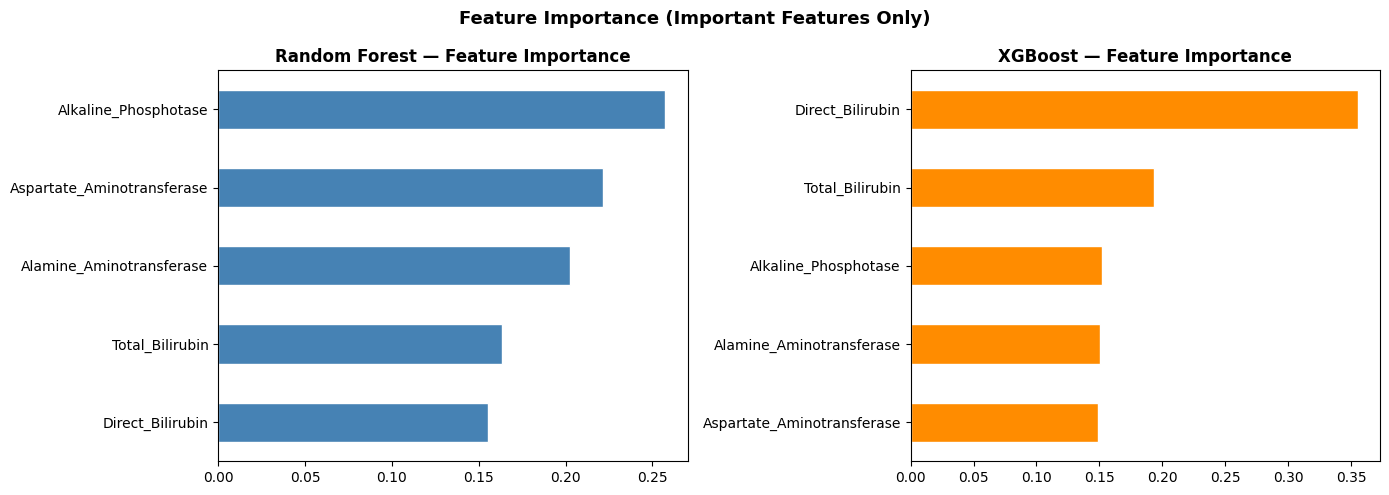

Top Feature (RF): Alkaline_Phosphotase
Top Feature (XGB): Direct_Bilirubin


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_imp  = pd.Series(full_trained['Random Forest'].feature_importances_, index=IMPORTANT_FEATURES)
xgb_imp = pd.Series(full_trained['XGBoost'].feature_importances_, index=IMPORTANT_FEATURES)

rf_imp.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Random Forest — Feature Importance', fontweight='bold')

xgb_imp.sort_values().plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('XGBoost — Feature Importance', fontweight='bold')

plt.suptitle('Feature Importance (Important Features Only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('2feature_importance2.png', dpi=100, bbox_inches='tight')
plt.show()

print('Top Feature (RF):', rf_imp.idxmax())
print('Top Feature (XGB):', xgb_imp.idxmax())


## 🟢 STEP 12: ROC Curves Comparison

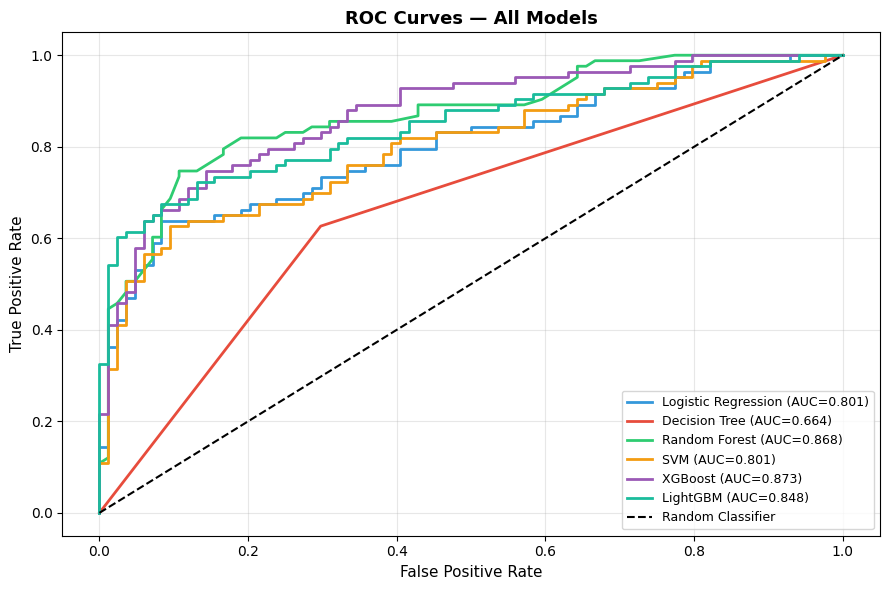

In [32]:
fig, ax = plt.subplots(figsize=(9, 6))
colors_roc = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c']

for (name, m), c in zip(full_trained.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_te, m.predict_proba(X_te)[:, 1])
    auc = roc_auc_score(y_te, m.predict_proba(X_te)[:, 1])
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=c, lw=2)

ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('2roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()


## 🟢 STEP 13: Save All Important Models

In [33]:
# Find best model for each category
def best_model_in(df_r, trained_dict, metric='ROC-AUC'):
    best_row = df_r.sort_values(metric, ascending=False).iloc[0]
    grp, name = best_row['Group'], best_row['Model']
    # get from the appropriate trained dict
    for d in [trained_dict.get(grp, {}), trained_dict]:
        if isinstance(d, dict) and name in d:
            return d[name], grp, name
    return None, grp, name

# Best Age model
age_best_m, age_best_g, age_best_n = best_model_in(age_df, age_trained)
# Best Gender model
gen_best_m, gen_best_g, gen_best_n = best_model_in(gender_df, gender_trained)
# Best Hybrid model (from standard 6)
hyb_best_m, hyb_best_g, hyb_best_n = best_model_in(hybrid_df, hybrid_trained)

# Save models
models_to_save = {
    'best_age_model.pkl':     age_best_m,
    'best_gender_model.pkl':  gen_best_m,
    'best_hybrid_model.pkl':  hyb_best_m,
    'stacking_model.pkl':     stacking_clf,
    'scaler_imp.pkl':         scaler_imp,
    'scaler_all.pkl':         scaler_all,
    'scaler_hybrid.pkl':      sc_h,
    'best_full_model.pkl':    full_trained[full_df.sort_values('ROC-AUC', ascending=False).iloc[0]['Model']],
}

for fname, obj in models_to_save.items():
    if obj is not None:
        with open(fname, 'wb') as f:
            pickle.dump(obj, f)
        print(f'  ✅ Saved: {fname}')

print(f'\n🏆 Best Age Model    : {age_best_n} [{age_best_g}]')
print(f'🏆 Best Gender Model : {gen_best_n} [{gen_best_g}]')
print(f'🏆 Best Hybrid Model : {hyb_best_n} [{hyb_best_g}]')
print(f'🏆 Best Full Model   : {full_df.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"]}')


  ✅ Saved: best_age_model.pkl
  ✅ Saved: best_gender_model.pkl
  ✅ Saved: best_hybrid_model.pkl
  ✅ Saved: stacking_model.pkl
  ✅ Saved: scaler_imp.pkl
  ✅ Saved: scaler_all.pkl
  ✅ Saved: scaler_hybrid.pkl
  ✅ Saved: best_full_model.pkl

🏆 Best Age Model    : Random Forest [Senior]
🏆 Best Gender Model : Random Forest [Male]
🏆 Best Hybrid Model : LightGBM [Senior_Male]
🏆 Best Full Model   : XGBoost
